In [1]:
# Cell 0 — Setup
!pip install -q cleanlab
from google.colab import drive
from pathlib import Path
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')
KOA_ROOT = Path('/content/drive/MyDrive/KOA')
NB4_OUT = KOA_ROOT / 'NB4'
NB4_OUT.mkdir(parents=True, exist_ok=True)
NB2_OUT = KOA_ROOT / 'NB2'

probs = np.load(str(NB2_OUT / 'nb2_probabilities.npy'))
labels = np.load(str(NB2_OUT / 'nb2_labels.npy'))
print(f"Probabilities: {probs.shape}")
print(f"Labels: {labels.shape}")
print(f"Distribution: {dict(Counter(labels))}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 19.2 MB/s eta 0:00:00
Mounted at /content/drive
Probabilities: (5778, 5)
Labels: (5778,)
Distribution: {np.int64(0): 2286, np.int64(1): 1046, np.int64(2): 1516, np.int64(3): 757, np.int64(4): 173}


In [2]:
# Cell 1 — Run CleanLab
from cleanlab.filter import find_label_issues

issue_mask = find_label_issues(labels, probs, return_indices_ranked_by='self_confidence')
n_flagged = len(issue_mask)
print(f"Total images: {len(labels)}")
print(f"Flagged as potentially mislabeled: {n_flagged} ({100*n_flagged/len(labels):.1f}%)")

flagged_set = set(issue_mask)
noise_by_grade = {}
for grade in range(5):
    grade_mask = labels == grade
    grade_indices = np.where(grade_mask)[0]
    flagged_in_grade = sum(1 for idx in grade_indices if idx in flagged_set)
    total_in_grade = len(grade_indices)
    pct = 100 * flagged_in_grade / total_in_grade if total_in_grade > 0 else 0
    noise_by_grade[grade] = {'flagged': flagged_in_grade, 'total': total_in_grade, 'pct': pct}
    print(f"  KL-{grade}: {flagged_in_grade}/{total_in_grade} ({pct:.1f}%)")

kl1_kl2 = noise_by_grade[1]['flagged'] + noise_by_grade[2]['flagged']
kl1_kl2_total = noise_by_grade[1]['total'] + noise_by_grade[2]['total']
print(f"\nKL-1 + KL-2 flagged: {kl1_kl2}/{kl1_kl2_total} ({100*kl1_kl2/kl1_kl2_total:.1f}%)")

Total images: 5778
Flagged as potentially mislabeled: 842 (14.6%)
  KL-0: 330/2286 (14.4%)
  KL-1: 193/1046 (18.5%)
  KL-2: 281/1516 (18.5%)
  KL-3: 38/757 (5.0%)
  KL-4: 0/173 (0.0%)

KL-1 + KL-2 flagged: 474/2562 (18.5%)


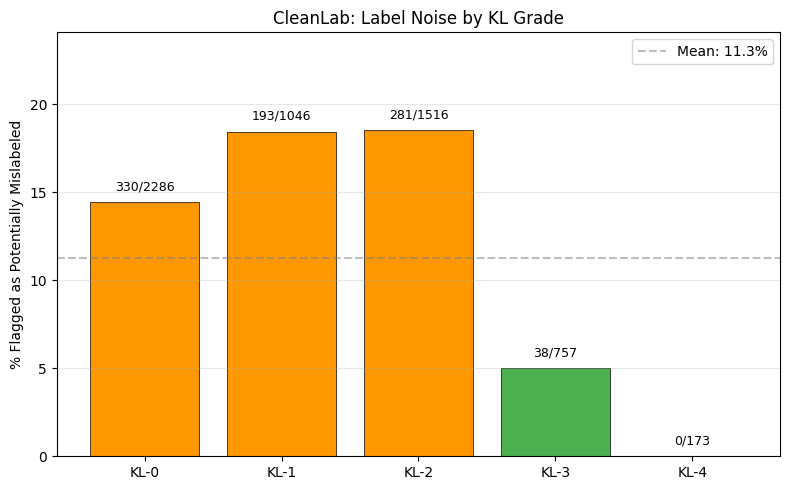

✓ nb4_noise_by_grade.png


In [3]:
# Cell 2 — Noise by Grade Bar Chart
NB4_OUT.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(8, 5))
grades = [f'KL-{i}' for i in range(5)]
pcts = [noise_by_grade[i]['pct'] for i in range(5)]
counts = [noise_by_grade[i]['flagged'] for i in range(5)]
totals = [noise_by_grade[i]['total'] for i in range(5)]

colors = ['#4CAF50' if p < 10 else '#FF9800' if p < 25 else '#F44336' for p in pcts]
bars = ax.bar(grades, pcts, color=colors, edgecolor='black', linewidth=0.5)
for bar, c, t in zip(bars, counts, totals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{c}/{t}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('% Flagged as Potentially Mislabeled')
ax.set_title('CleanLab: Label Noise by KL Grade')
ax.set_ylim(0, max(pcts) * 1.3)
ax.axhline(y=np.mean(pcts), color='gray', linestyle='--', alpha=0.5, label=f'Mean: {np.mean(pcts):.1f}%')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(str(NB4_OUT / 'nb4_noise_by_grade.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ nb4_noise_by_grade.png")

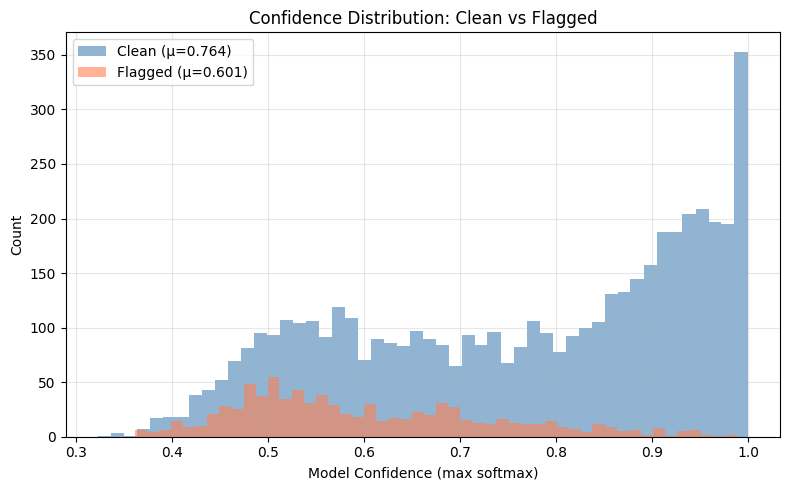

Clean mean conf: 0.7642 | Flagged mean conf: 0.6011


In [4]:
# Cell 3 — Confidence Distribution
clean_mask = np.ones(len(labels), dtype=bool)
clean_mask[issue_mask] = False

clean_conf = np.max(probs[clean_mask], axis=1)
flagged_conf = np.max(probs[~clean_mask], axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(clean_conf, bins=50, alpha=0.6, label=f'Clean (μ={clean_conf.mean():.3f})', color='steelblue')
ax.hist(flagged_conf, bins=50, alpha=0.6, label=f'Flagged (μ={flagged_conf.mean():.3f})', color='coral')
ax.set_xlabel('Model Confidence (max softmax)')
ax.set_ylabel('Count')
ax.set_title('Confidence Distribution: Clean vs Flagged')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(str(NB4_OUT / 'nb4_confidence.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Clean mean conf: {clean_conf.mean():.4f} | Flagged mean conf: {flagged_conf.mean():.4f}")

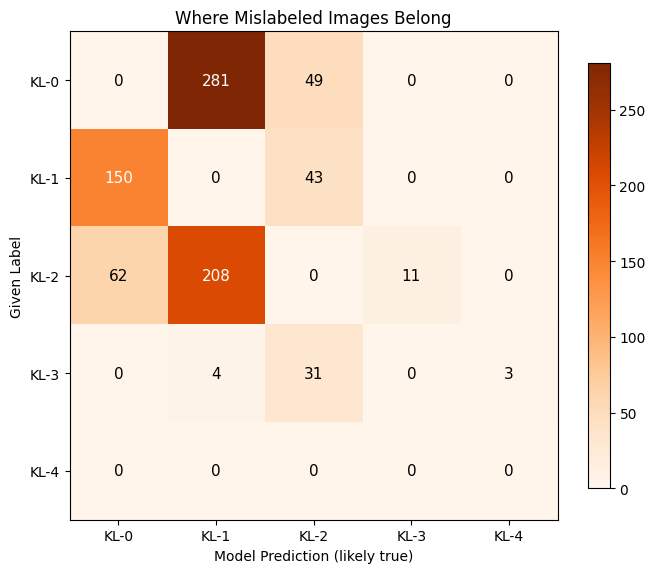

✓ nb4_transition.png


In [5]:
# Cell 4 — Noise Transition Matrix
predicted_labels = np.argmax(probs, axis=1)
flagged_true = labels[issue_mask]
flagged_pred = predicted_labels[issue_mask]

from sklearn.metrics import confusion_matrix
transition = confusion_matrix(flagged_true, flagged_pred, labels=range(5))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(transition, cmap='Oranges', interpolation='nearest')
ax.set_xticks(range(5)); ax.set_yticks(range(5))
ax.set_xticklabels([f'KL-{i}' for i in range(5)])
ax.set_yticklabels([f'KL-{i}' for i in range(5)])
ax.set_xlabel('Model Prediction (likely true)')
ax.set_ylabel('Given Label')
ax.set_title('Where Mislabeled Images Belong')
for i in range(5):
    for j in range(5):
        ax.text(j, i, str(transition[i,j]), ha='center', va='center', fontsize=11,
                color='white' if transition[i,j] > transition.max()*0.5 else 'black')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
fig.savefig(str(NB4_OUT / 'nb4_transition.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ nb4_transition.png")

In [6]:
# Cell 5 — Theoretical Bound + Connection
kl1_noise_rate = noise_by_grade[1]['pct'] / 100
theoretical_max_f1 = 1 - 2 * kl1_noise_rate

nb2_path = KOA_ROOT / 'NB2' / 'nb2_results.json'
if nb2_path.exists():
    with open(str(nb2_path)) as f:
        nb2 = json.load(f)
    observed_kl1_f1_vals = []
    for arch in nb2.get('results', {}):
        for loss in nb2['results'][arch]:
            for f1_list in nb2['results'][arch][loss].get('f1', []):
                if len(f1_list) > 1:
                    observed_kl1_f1_vals.append(f1_list[1])
    observed_kl1_f1 = np.mean(observed_kl1_f1_vals) if observed_kl1_f1_vals else 0.39
else:
    observed_kl1_f1 = 0.39

nb1_path = KOA_ROOT / 'NB1' / 'nb1_summary.json'
interrater_kappa = None
if nb1_path.exists():
    with open(str(nb1_path)) as f:
        nb1 = json.load(f)
    interrater_kappa = nb1.get('interrater_kappa')

print("CONNECTION: NB1 → NB4 → NB2")
print("=" * 60)
print(f"NB1 inter-rater kappa: {interrater_kappa}")
print(f"NB4 CleanLab KL-1 noise: {noise_by_grade[1]['pct']:.1f}%")
print(f"NB4 CleanLab KL-2 noise: {noise_by_grade[2]['pct']:.1f}%")
print(f"NB2 observed KL-1 F1: {observed_kl1_f1:.3f}")
print(f"Theoretical max F1 (given {kl1_noise_rate:.0%} noise): {theoretical_max_f1:.3f}")

CONNECTION: NB1 → NB4 → NB2
NB1 inter-rater kappa: 1.0
NB4 CleanLab KL-1 noise: 18.5%
NB4 CleanLab KL-2 noise: 18.5%
NB2 observed KL-1 F1: 0.355
Theoretical max F1 (given 18% noise): 0.631


In [7]:
# Cell 6 — Save Results
nb4_results = {
    'total_flagged': int(n_flagged),
    'total_images': int(len(labels)),
    'flagged_pct': float(100 * n_flagged / len(labels)),
    'noise_by_grade': {str(k): v for k, v in noise_by_grade.items()},
    'clean_mean_confidence': float(clean_conf.mean()),
    'flagged_mean_confidence': float(flagged_conf.mean()),
    'kl1_noise_rate': float(kl1_noise_rate),
    'theoretical_max_f1': float(theoretical_max_f1),
}
with open(str(NB4_OUT / 'nb4_cleanlab.json'), 'w') as f:
    json.dump(nb4_results, f, indent=2)

for fn in ['nb4_cleanlab.json', 'nb4_noise_by_grade.png', 'nb4_confidence.png', 'nb4_transition.png']:
    print(f"  {'✓' if (NB4_OUT / fn).exists() else '✗'} {fn}")

  ✓ nb4_cleanlab.json
  ✓ nb4_noise_by_grade.png
  ✓ nb4_confidence.png
  ✓ nb4_transition.png
